# Binary Federated Intrusion Detection on DNN-EdgeIIoT

**Goal.** Demonstrate a simple, reliable **federated-learning** workflow for
binary intrusion detection (`0 = Normal`, `1 = Attack`) using **PyTorch** and
the **Flower** framework with standard **FedAvg** aggregation across five
simulated factory clients.

This notebook is deliberately kept readable: the heavy lifting lives in the
`src/` package, and each step here shows its real output. The pipeline is:

1. Load & inspect the DNN-EdgeIIoT dataset.
2. Clean it and remove identifier/leakage columns.
3. Draw a balanced 10% subset (50% Normal / 50% Attack).
4. Split 70/15/15 into train-pool / validation / test.
5. Fit preprocessing **only** on the training pool.
6. Train a centralized DNN baseline (for comparison).
7. Partition the training pool IID across 5 clients.
8. Run federated training with Flower FedAvg.
9. Evaluate both models once on the untouched test set and compare.

> **Note on accuracy.** The DNN-EdgeIIoT *binary* task is near-perfectly
> separable, so both models reach ~99–100%. Section 6 shows *why* (several
> protocol fields separate the classes on their own). This is the honest,
> literature-consistent result for this dataset, not a bug — see the
> limitations at the end.

## 1. Imports and reproducibility

We add the project root to `sys.path` so `src` is importable whether the
notebook is launched from `notebooks/` or from the project root, then seed
Python/NumPy/PyTorch for reproducibility.

In [1]:
import sys, pathlib, json, time, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Make the `src` package importable from either the project root or notebooks/.
here = pathlib.Path.cwd()
ROOT = here if (here / "src").exists() else here.parent
sys.path.insert(0, str(ROOT))

from src.config import CONFIG, DATASET_PATH, TARGET_COLUMN, CLASS_NAMES, ensure_dirs
from src import config as cfgmod
from src import data as datamod
from src import preprocessing as prep
from src.partitioning import iid_partition, partition_distribution, assert_valid_partitions
from src.model import build_model, set_seed
from src import training as trainmod
from src import evaluation as evalmod
from src.federated import run_federated

warnings.filterwarnings("ignore", category=FutureWarning)
ensure_dirs()
set_seed(CONFIG.random_seed)
pd.set_option("display.width", 120)
print("Project root:", ROOT)
print("Random seed :", CONFIG.random_seed)

Project root: <local-project-root>\edgeiiot_federated
Random seed : 42


## 2. Environment and CUDA verification

CUDA should appear as available and the detected GPU name will confirm PyTorch
can use the laptop GPU. The **centralized** baseline trains on this GPU; the
**federated** clients run on CPU (explained in Section 14).

In [2]:
import flwr, sklearn
print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__)
print("CUDA build  :", torch.version.cuda)
print("CUDA avail  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
print("Flower      :", flwr.__version__)
print("scikit-learn:", sklearn.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training device (centralized):", device)

Python      : 3.11.0
PyTorch     : 2.5.1+cu121
CUDA build  : 12.1
CUDA avail  : True
GPU         : NVIDIA GeForce RTX 3050 6GB Laptop GPU
Flower      : 1.32.1
scikit-learn: 1.9.0
Training device (centralized): cuda


## 3. Hyperparameter configuration

Every tunable knob lives in `src/config.py` (one `dataclass`). The table below
documents what raising/lowering each key setting tends to do.

In [3]:
from dataclasses import asdict
cfg_dict = asdict(CONFIG)
print(json.dumps({k: v for k, v in cfg_dict.items()}, indent=2, default=str))

{
  "random_seed": 42,
  "dataset_fraction": 0.1,
  "normal_attack_ratio": 0.5,
  "validation_fraction": 0.15,
  "test_fraction": 0.15,
  "num_clients": 5,
  "client_names": [
    "Factory_A",
    "Factory_B",
    "Factory_C",
    "Factory_D",
    "Factory_E"
  ],
  "hidden_layers": [
    128,
    64,
    32
  ],
  "dropout_rates": [
    0.2,
    0.1
  ],
  "learning_rate": 0.001,
  "weight_decay": 0.0,
  "batch_size": 256,
  "centralized_epochs": 15,
  "early_stopping_patience": 5,
  "local_epochs": 2,
  "federated_rounds": 10,
  "fraction_fit": 1.0,
  "fraction_evaluate": 0.0,
  "decision_threshold": 0.5,
  "use_smote": false,
  "max_categorical_cardinality": 50
}


In [4]:
tuning_guide = pd.DataFrame([
    ("dataset_fraction", CONFIG.dataset_fraction, "More data, slower, usually better", "Less data, faster, may underfit"),
    ("learning_rate", CONFIG.learning_rate, "Faster but may diverge/oscillate", "Slower, steadier convergence"),
    ("batch_size", CONFIG.batch_size, "Faster epochs, smoother, may generalize worse", "Noisier updates, sometimes better generalization"),
    ("dropout_rates", str(CONFIG.dropout_rates), "More regularization, less overfit", "Less regularization, risk overfit"),
    ("centralized_epochs", CONFIG.centralized_epochs, "More fitting, risk overfit", "Less fitting, risk underfit"),
    ("local_epochs", CONFIG.local_epochs, "Clients drift further per round (client-shift)", "Slower global progress per round"),
    ("federated_rounds", CONFIG.federated_rounds, "More global aggregation, better/slower", "Fewer rounds, faster/undertrained"),
    ("num_clients", CONFIG.num_clients, "More parallel sites, smaller shards each", "Fewer sites, larger shards each"),
    ("decision_threshold", CONFIG.decision_threshold, "Fewer positives -> higher precision, lower recall", "More positives -> higher recall, lower precision"),
], columns=["hyperparameter", "current", "increasing it", "decreasing it"])
tuning_guide

,hyperparameter,current,increasing it,decreasing it
0,dataset_fraction,0.1,"More data, slower, usually better","Less data, faster, may underfit"
1,learning_rate,0.001,Faster but may diverge/oscillate,"Slower, steadier convergence"
2,batch_size,256,"Faster epochs, smoother, may generalize worse","Noisier updates, sometimes better generalization"
3,dropout_rates,"[0.2, 0.1]","More regularization, less overfit","Less regularization, risk overfit"
4,centralized_epochs,15,"More fitting, risk overfit","Less fitting, risk underfit"
5,local_epochs,2,Clients drift further per round (client-shift),Slower global progress per round
6,federated_rounds,10,"More global aggregation, better/slower","Fewer rounds, faster/undertrained"
7,num_clients,5,"More parallel sites, smaller shards each","Fewer sites, larger shards each"
8,decision_threshold,0.5,"Fewer positives -> higher precision, lower recall","More positives -> higher recall, lower precision"


## 4. Dataset loading

We load the full DNN-EdgeIIoT CSV (~1.2 GB). The path is defined once in
`src/config.py` (override with the `EDGEIIOT_DATASET` env var). Loading takes
roughly half a minute.

In [5]:
assert DATASET_PATH.exists(), f"Dataset not found: {DATASET_PATH}"
t0 = time.time()
raw = datamod.load_dataset(DATASET_PATH)
print(f"Loaded {raw.shape[0]:,} rows x {raw.shape[1]} columns in {time.time()-t0:.1f}s")
raw.head(3)

Loaded 2,219,201 rows x 63 columns in 27.7s


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal


## 5. Dataset inspection

The report below covers rows, columns, dtypes, class distribution, missing /
infinity counts, duplicate rows and approximate memory usage — the raw-data
health check before any cleaning.

In [6]:
info = datamod.inspect_dataset(raw)
print(f"Rows            : {info['n_rows']:,}")
print(f"Columns         : {info['n_columns']}")
print(f"Memory (approx) : {info['memory_mb']:.1f} MB")
print(f"Duplicate rows  : {info['n_duplicate_rows']:,}")
print(f"Total missing   : {info['total_missing']:,}")
print(f"Total infinities: {info['total_infinities']:,}")
print(f"Label counts    : {info['label_counts']}")
lab = raw[TARGET_COLUMN].value_counts()
print("\nClass distribution (raw):")
for k in sorted(lab.index):
    print(f"  {k} ({CLASS_NAMES[int(k)]}): {lab[k]:,}  ({100*lab[k]/len(raw):.2f}%)")

Rows            : 2,219,201
Columns         : 63
Memory (approx) : 1787.8 MB
Duplicate rows  : 815
Total missing   : 0
Total infinities: 0
Label counts    : {'0': 1615643, '1': 603558}

Class distribution (raw):
  0 (Normal): 1,615,643  (72.80%)
  1 (Attack): 603,558  (27.20%)


In [7]:
dtypes_df = pd.DataFrame({"column": info["columns"],
                          "dtype": [info["dtypes"][c] for c in info["columns"]]})
print("Columns and dtypes:")
dtypes_df

Columns and dtypes:


,column,dtype
0,frame.time,str
1,ip.src_host,str
2,ip.dst_host,str
3,arp.dst.proto_ipv4,str
4,arp.opcode,float64
...,...,...
58,mbtcp.len,float64
59,mbtcp.trans_id,float64
60,mbtcp.unit_id,float64
61,Attack_label,int64


## 6. Cleaning and leakage checks

Cleaning removes duplicate rows (before any split), replaces ±infinity with
NaN, drops the multiclass `Attack_type` column, and drops identifier /
leakage-prone columns (IP addresses, timestamps, raw payloads/URIs/messages,
ports, constant columns). Each removal is recorded with a reason.

In [8]:
clean, dropped_report = datamod.clean_dataset(raw, CONFIG)
print(f"Cleaned shape       : {clean.shape}")
print(f"Duplicate rows removed: {clean.attrs['n_duplicate_rows_removed']:,}")
print(f"Columns dropped     : {len(dropped_report)}")
# Free the ~1.8 GB raw frame; the notebook only needs the cleaned data now.
del raw
dropped_report

Cleaned shape       : (2218386, 42)
Duplicate rows removed: 815
Columns dropped     : 21


,column,reason,category
0,Attack_type,Detailed attack category; directly reveals the...,target-leakage
1,frame.time,Packet capture timestamp; encodes when each at...,identifier
2,ip.src_host,"Source IP address; identifies the lab host, no...",identifier
3,ip.dst_host,Destination IP address; identifies the lab victim,identifier
4,arp.src.proto_ipv4,Source IPv4 in ARP; host identifier,identifier
5,arp.dst.proto_ipv4,Destination IPv4 in ARP; host identifier,identifier
6,icmp.transmit_timestamp,ICMP timestamp; encodes capture time,identifier
7,tcp.payload,Raw TCP payload bytes; leaks attack content ve...,leakage-prone
8,mqtt.msg,Raw MQTT message payload; leaks attack content,leakage-prone
9,http.file_data,Raw HTTP body; leaks attack content,leakage-prone


**Why is accuracy so high? A transparency check.** Below we measure, for each
remaining feature, how well a *single* feature alone separates Normal from
Attack. Several protocol-metadata fields separate the classes almost perfectly,
which is why any reasonable model reaches ~100%. We keep these features (they
are legitimate protocol metadata, not identifiers), but this table makes the
dataset's near-perfect separability explicit and honest.

In [9]:
def single_feature_separability(df, target=TARGET_COLUMN, top=12):
    y = df[target].to_numpy()
    rows = []
    for c in df.columns:
        if c == target:
            continue
        col = df[c]
        if pd.api.types.is_numeric_dtype(col):
            x = col.fillna(col.median()).to_numpy()
            nz = (x != 0).astype(int)
            acc = max((nz == y).mean(), (nz != y).mean())  # best of rule / its inverse
        else:
            ct = pd.crosstab(col.fillna("NA"), y)
            acc = float((ct.max(axis=1) / ct.sum(axis=1) * ct.sum(axis=1) / len(df)).sum())
        rows.append((c, round(float(acc), 4)))
    return pd.DataFrame(rows, columns=["feature", "single_feature_accuracy"]) \
             .sort_values("single_feature_accuracy", ascending=False).head(top).reset_index(drop=True)

sep = single_feature_separability(clean)
sep

,feature,single_feature_accuracy
0,dns.qry.name.len,1.0000
1,mqtt.conack.flags,1.0000
2,mqtt.protoname,1.0000
3,mqtt.topic,1.0000
4,http.request.version,0.8434
5,http.request.method,0.8432
6,tcp.flags,0.8335
7,tcp.checksum,0.8335
8,tcp.seq,0.7950
9,icmp.seq_le,0.7861


Basic cleaning assertions: no infinities remain in numeric columns and the
target contains only 0/1.

In [10]:
num_only = clean.select_dtypes(include=[np.number])
assert not np.isinf(num_only.to_numpy(dtype="float64", na_value=np.nan)).any(), "infinities remain"
assert set(clean[TARGET_COLUMN].unique()) <= {0, 1}, "target has non-binary values"
print("OK: no infinities; target is binary (0/1).")

OK: no infinities; target is binary (0/1).


## 7. Balanced 10% sampling

We take ~10% of the cleaned dataset, balanced 50/50 by drawing an equal number
of Normal and Attack rows (seed 42), then shuffle. If a class were too small,
the largest feasible equal count would be used — the printed counts confirm the
actual result.

In [11]:
print("Before balancing (cleaned):", clean[TARGET_COLUMN].value_counts().to_dict())
sample = datamod.balanced_sample(clean, CONFIG)
counts = sample[TARGET_COLUMN].value_counts().to_dict()
print("After balancing (subset)  :", counts)
print(f"Subset size: {len(sample):,} rows "
      f"(~{100*len(sample)/len(clean):.1f}% of cleaned)")
assert counts.get(0) == counts.get(1), "subset is not 50/50 balanced"
del clean

Before balancing (cleaned): {0: 1615643, 1: 602743}


After balancing (subset)  : {1: 110919, 0: 110919}
Subset size: 221,838 rows (~10.0% of cleaned)


## 8. Train / validation / test split

Stratified 70/15/15 split (seed 42). The **test set is untouched** until the
final evaluation. Assertions prove the three index sets are disjoint.

In [12]:
train_pool, val_df, test_df = datamod.split_data(sample, CONFIG)
print(f"Train pool : {len(train_pool):,}  ({train_pool[TARGET_COLUMN].mean():.3f} attack frac)")
print(f"Validation : {len(val_df):,}  ({val_df[TARGET_COLUMN].mean():.3f} attack frac)")
print(f"Test       : {len(test_df):,}  ({test_df[TARGET_COLUMN].mean():.3f} attack frac)")

# Save raw test rows for the inference demo (untouched features).
cfgmod.ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
test_df.to_csv(cfgmod.ARTIFACTS_DIR / "test_raw.csv", index=False)

# Disjointness by (unique) sample-row index -- the actual requirement.
itr, iva, ite = set(train_pool.index), set(val_df.index), set(test_df.index)
assert itr.isdisjoint(iva) and itr.isdisjoint(ite) and iva.isdisjoint(ite), "split indices overlap!"
assert len(itr) + len(iva) + len(ite) == len(sample), "splits do not cover the subset exactly"
print("OK: train / validation / test row indices are disjoint and cover the subset.")

# Transparency note: because 21 columns were dropped after de-duplication,
# some *distinct* original records can coincide in the reduced feature space.
# That is a property of the dataset, not train/test index leakage.
dup_content = pd.concat([train_pool, test_df]).duplicated().sum()
print(f"(Content-identical rows shared across train+test after column drops: {dup_content:,})")

Train pool : 155,286  (0.500 attack frac)
Validation : 33,276  (0.500 attack frac)
Test       : 33,276  (0.500 attack frac)


OK: train / validation / test row indices are disjoint and cover the subset.


(Content-identical rows shared across train+test after column drops: 4,657)


## 9. Preprocessing

The `ColumnTransformer` is fit **only on the training pool** (no leakage from
val/test). Numeric features → median impute + StandardScaler; low-cardinality
categoricals → most-frequent impute + one-hot (unknown-safe). High-cardinality
text-like categoricals are dropped. Outputs are `float32`. The fitted
preprocessor, feature names and dataset summary are saved to `artifacts/`.

In [13]:
X_tr_df, y_tr = datamod.split_features_target(train_pool)
X_va_df, y_va = datamod.split_features_target(val_df)
X_te_df, y_te = datamod.split_features_target(test_df)

num_cols, cat_cols, extra_dropped = prep.identify_feature_types(X_tr_df, CONFIG)
keep_cols = num_cols + cat_cols
print(f"Numeric features    : {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)} -> {cat_cols}")
if extra_dropped:
    print(f"Extra dropped (high-cardinality): {[d['column'] for d in extra_dropped]}")

preprocessor = prep.build_preprocessor(num_cols, cat_cols).fit(X_tr_df[keep_cols])
X_tr = prep.transform_to_float32(preprocessor, X_tr_df[keep_cols])
X_va = prep.transform_to_float32(preprocessor, X_va_df[keep_cols])
X_te = prep.transform_to_float32(preprocessor, X_te_df[keep_cols])
feature_names = prep.get_feature_names(preprocessor, num_cols, cat_cols)
input_dim = X_tr.shape[1]
print(f"Processed feature matrix: {X_tr.shape} (input_dim={input_dim})")

# Final preprocessing assertions.
for name, arr in [("train", X_tr), ("val", X_va), ("test", X_te)]:
    assert not np.isnan(arr).any(), f"NaN in {name}"
    assert not np.isinf(arr).any(), f"Inf in {name}"
    assert arr.dtype == np.float32, f"{name} not float32"
print("OK: no NaN/Inf; all float32.")

Numeric features    : 35
Categorical features: 6 -> ['http.request.method', 'http.request.version', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.protoname', 'mqtt.topic']


Processed feature matrix: (155286, 72) (input_dim=72)
OK: no NaN/Inf; all float32.


In [14]:
import joblib
joblib.dump(preprocessor, cfgmod.PREPROCESSOR_PATH)

# Combine the base drop report with any high-cardinality drops from preprocessing.
full_dropped = pd.concat([dropped_report, pd.DataFrame(extra_dropped)], ignore_index=True) \
    if extra_dropped else dropped_report
full_dropped.to_csv(cfgmod.DROPPED_COLUMNS_PATH, index=False)

with open(cfgmod.FEATURE_NAMES_PATH, "w") as f:
    json.dump({
        "input_columns": keep_cols,          # raw columns the preprocessor consumes
        "numeric_columns": num_cols,
        "categorical_columns": cat_cols,
        "output_feature_names": feature_names,  # names after one-hot expansion
        "n_output_features": int(input_dim),
    }, f, indent=2)

summary = {
    "dataset_file": DATASET_PATH.name,
    "subset_rows": int(len(sample)),
    "train_rows": int(len(train_pool)),
    "val_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "n_input_features": int(input_dim),
    "n_dropped_columns": int(len(full_dropped)),
    "config": {k: (v if not isinstance(v, (list, tuple)) else list(v)) for k, v in cfg_dict.items()},
}
with open(cfgmod.DATA_SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=2, default=str)
print("Saved: preprocessor.joblib, feature_names.json, dropped_columns.csv, data_summary.json")

Saved: preprocessor.joblib, feature_names.json, dropped_columns.csv, data_summary.json


## 10. Centralized DNN baseline

The shared MLP trained on the whole training pool at once, with early stopping
on validation F1. This is the reference the federated model is compared against.
The architecture (same for every client) is printed first.

In [15]:
set_seed(CONFIG.random_seed)
baseline = build_model(input_dim, CONFIG)
print(baseline)
n_params = sum(p.numel() for p in baseline.parameters())
print(f"\nTrainable parameters: {n_params:,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=72, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 19,713


In [16]:
set_seed(CONFIG.random_seed)
baseline, history, best_val, cen_train_time = trainmod.train_centralized(
    baseline, X_tr, y_tr, X_va, y_va, CONFIG, device, verbose=True)
print(f"\nCentralized training time: {cen_train_time:.1f}s")
print("Best validation:", evalmod.format_metrics(best_val))

  epoch 01/15 | train_loss=0.0293 val_loss=0.0000 val_acc=1.0000 val_f1=1.0000  <-- best


  epoch 02/15 | train_loss=0.0000 val_loss=0.0000 val_acc=1.0000 val_f1=1.0000


  epoch 03/15 | train_loss=0.0001 val_loss=0.0000 val_acc=1.0000 val_f1=1.0000


  epoch 04/15 | train_loss=0.0000 val_loss=0.0000 val_acc=1.0000 val_f1=1.0000


  epoch 05/15 | train_loss=0.0000 val_loss=0.0000 val_acc=1.0000 val_f1=1.0000


  epoch 06/15 | train_loss=0.0000 val_loss=0.0000 val_acc=1.0000 val_f1=1.0000
  early stopping at epoch 6 (no val-F1 gain for 5 epochs)

Centralized training time: 18.3s
Best validation: acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000 roc_auc=1.0000 pr_auc=1.0000


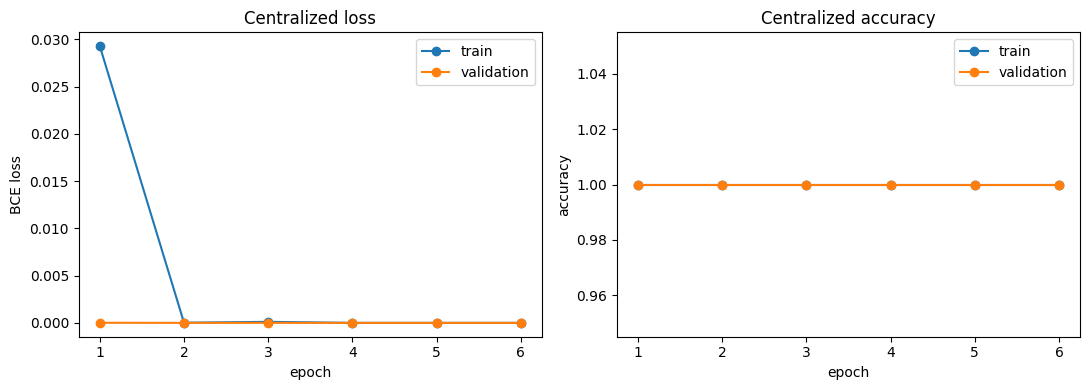

In [17]:
fig = evalmod.plot_training_curves(history, "Centralized")
plt.show()

## 11. Limited hyperparameter comparison

A small, deliberately non-exhaustive comparison of a few architectures /
learning rates / dropout / batch sizes. Each candidate is trained briefly and
scored by **validation F1** (never the test set). On this easily separable data
the candidates are all strong; we still pick the best-F1 (tie-break: fastest).

In [18]:
from copy import deepcopy
candidates = [
    {"hidden_layers": [128, 64, 32], "learning_rate": 0.001,  "dropout_rates": [0.20, 0.10], "batch_size": 256},
    {"hidden_layers": [256, 128, 64], "learning_rate": 0.001, "dropout_rates": [0.20, 0.10], "batch_size": 256},
    {"hidden_layers": [128, 64, 32], "learning_rate": 0.0003, "dropout_rates": [0.10, 0.10], "batch_size": 128},
    {"hidden_layers": [128, 64, 32], "learning_rate": 0.001,  "dropout_rates": [0.20, 0.10], "batch_size": 128},
]
rows = []
for i, ov in enumerate(candidates):
    c = deepcopy(CONFIG)
    for k, v in ov.items():
        setattr(c, k, v)
    c.centralized_epochs = 8  # short comparison runs
    set_seed(CONFIG.random_seed)
    m = build_model(input_dim, c)
    m, _, bv, tt = trainmod.train_centralized(m, X_tr, y_tr, X_va, y_va, c, device, verbose=False)
    rows.append({
        "arch": str(ov["hidden_layers"]), "lr": ov["learning_rate"],
        "batch": ov["batch_size"], "dropout": str(ov["dropout_rates"]),
        "val_acc": round(bv["accuracy"], 4), "val_f1": round(bv["f1"], 4),
        "train_time_s": round(tt, 1),
    })
results_hp = pd.DataFrame(rows).sort_values(["val_f1", "train_time_s"], ascending=[False, True]).reset_index(drop=True)
results_hp

,arch,lr,batch,dropout,val_acc,val_f1,train_time_s
0,"[128, 64, 32]",0.0010,256,"[0.2, 0.1]",1.0,1.0,19.4
1,"[256, 128, 64]",0.0010,256,"[0.2, 0.1]",1.0,1.0,20.7
2,"[128, 64, 32]",0.0003,128,"[0.1, 0.1]",1.0,1.0,24.7
3,"[128, 64, 32]",0.0010,128,"[0.2, 0.1]",1.0,1.0,25.0


## 12. Final model selection

We report which candidate won on validation F1. The default config
(`[128, 64, 32]`, lr 1e-3) is already competitive, so we keep it as the shared
architecture for **all five federated clients** (identical models are what makes
FedAvg valid), and evaluate the trained centralized baseline **once** on the
untouched test set.

In [19]:
best_row = results_hp.iloc[0]
print("Best candidate by validation F1:")
print(best_row.to_string())
print("\nKeeping the default architecture for the federated clients (identical models).")

# Persist and test-evaluate the centralized baseline (single, final use of test set).
torch.save(baseline.state_dict(), cfgmod.CENTRALIZED_MODEL_PATH)
cen_test = trainmod.evaluate(baseline, X_te, y_te, device, CONFIG.decision_threshold)
print("\nCentralized TEST metrics:")
print(evalmod.format_metrics(cen_test))
print(f"Confusion: TN={cen_test['tn']} FP={cen_test['fp']} FN={cen_test['fn']} TP={cen_test['tp']}")

Best candidate by validation F1:
arch            [128, 64, 32]
lr                      0.001
batch                     256
dropout            [0.2, 0.1]
val_acc                   1.0
val_f1                    1.0
train_time_s             19.4

Keeping the default architecture for the federated clients (identical models).

Centralized TEST metrics:
acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000 roc_auc=1.0000 pr_auc=1.0000
Confusion: TN=16638 FP=0 FN=0 TP=16638


## 13. IID five-client partitioning

The training pool is split IID across the five factories: each gets a random,
class-balanced slice (~equal size, ~50/50). Assertions confirm exactly five
non-empty, disjoint partitions that together cover the whole pool.

In [20]:
partitions = iid_partition(y_tr, CONFIG.num_clients, CONFIG.client_names, CONFIG.random_seed)
assert_valid_partitions(partitions, y_tr, CONFIG.num_clients)
dist = partition_distribution(partitions, y_tr)
dist.to_csv(cfgmod.CLIENT_DISTRIBUTIONS_PATH, index=False)
dist

,client,total,normal,attack,normal_pct,attack_pct
0,Factory_A,31058,15529,15529,50.0,50.0
1,Factory_B,31058,15529,15529,50.0,50.0
2,Factory_C,31058,15529,15529,50.0,50.0
3,Factory_D,31056,15528,15528,50.0,50.0
4,Factory_E,31056,15528,15528,50.0,50.0


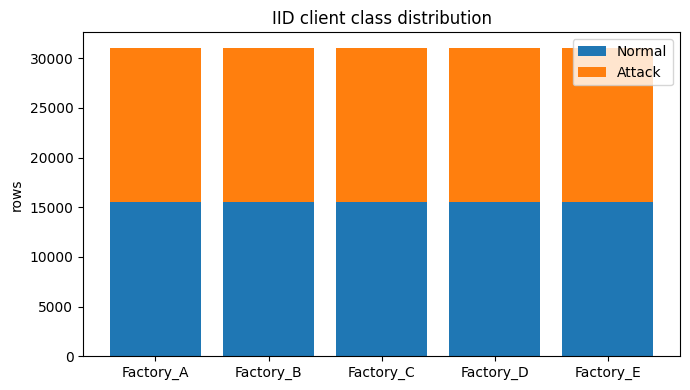

In [21]:
fig = evalmod.plot_client_distribution(dist)
plt.show()

## 14. Flower client and server setup

We use Flower's simulation engine with the `NumPyClient` API:

- **Client** (`src/client_app.py`): loads global weights → trains locally for
  `local_epochs` on **only its own shard** → returns updated weights,
  `num_examples`, and local metrics.
- **Server** (`src/server_app.py`): `FedAvg` with **sample-count-weighted**
  averaging, all 5 clients every round; after each round it evaluates the
  aggregated model on the central validation set and checkpoints the best-F1
  global model.

**Resource choice.** The MLP is tiny, so clients run on **CPU** (1 CPU each).
Running five concurrent clients on the 6 GB laptop GPU via Ray adds memory
contention and instability for no speed benefit here — reliability first.

In [22]:
fed_settings = pd.DataFrame([
    ("num_clients", CONFIG.num_clients),
    ("federated_rounds", CONFIG.federated_rounds),
    ("local_epochs", CONFIG.local_epochs),
    ("fraction_fit", CONFIG.fraction_fit),
    ("min_fit_clients", CONFIG.num_clients),
    ("min_available_clients", CONFIG.num_clients),
    ("aggregation", "FedAvg (sample-count weighted)"),
    ("client_device", "cpu"),
], columns=["setting", "value"])
fed_settings

,setting,value
0,num_clients,5
1,federated_rounds,10
2,local_epochs,2
3,fraction_fit,1.0
4,min_fit_clients,5
5,min_available_clients,5
6,aggregation,FedAvg (sample-count weighted)
7,client_device,cpu


## 15. Federated training with FedAvg

This runs the full simulation. Round 0 is the random initialisation; each later
round shows the aggregated global model's validation metrics. Flower prints its
own progress log; the per-round table is collected afterwards.

In [23]:
set_seed(CONFIG.random_seed)
fed = run_federated(
    X_tr, y_tr, partitions, X_va, y_va, input_dim, CONFIG,
    client_device="cpu", verbose_logging=False,
)
round_metrics = fed["round_metrics"]
client_metrics = fed["client_metrics"]
print(f"\nSimulation wall time: {fed['wall_time']:.1f}s")
print(f"Best global model: round {fed['best']['round']} (val F1 = {fed['best']['f1']:.4f})")
round_metrics


            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        


INFO :      Starting Flower ServerApp, config: num_rounds=10, no round_timeout


INFO :      


INFO :      [INIT]


INFO :      Using initial global parameters provided by strategy


...

INFO :      	                (10, 1.0)]}


INFO :      


(ClientAppActor pid=25388) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=27004) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=31796) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=28044) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=28288) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=31908) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=26776) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=34476) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=30512) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=19072) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=8984) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=20944) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=29368) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=34588)


Simulation wall time: 51.9s
Best global model: round 1 (val F1 = 1.0000)


,round,val_loss,val_acc,val_precision,val_recall,val_f1,val_roc_auc
0,0,6.953784e-01,0.49988,0.0,0.0,0.0,0.496838
1,1,7.447923e-05,1.00000,1.0,1.0,1.0,1.000000
2,2,1.089300e-08,1.00000,1.0,1.0,1.0,1.000000
3,3,2.109611e-11,1.00000,1.0,1.0,1.0,1.000000
4,4,6.135342e-12,1.00000,1.0,1.0,1.0,1.000000
5,5,1.213793e-12,1.00000,1.0,1.0,1.0,1.000000
6,6,9.323229e-13,1.00000,1.0,1.0,1.0,1.000000
7,7,1.375122e-12,1.00000,1.0,1.0,1.0,1.000000
8,8,9.291858e-13,1.00000,1.0,1.0,1.0,1.000000
9,9,5.098668e-13,1.00000,1.0,1.0,1.0,1.000000


In [24]:
print("Per-client training metrics (first rounds):")
client_metrics.head(15)

Per-client training metrics (first rounds):


,round,client_name,partition_id,num_examples,train_loss,train_acc,train_f1
0,1,Factory_A,0,31058,7.841268e-05,1.0,1.0
1,1,Factory_B,1,31058,5.149242e-05,1.0,1.0
2,1,Factory_C,2,31058,7.837701e-05,1.0,1.0
3,1,Factory_D,3,31056,6.103913e-05,1.0,1.0
4,1,Factory_E,4,31056,6.502443e-05,1.0,1.0
5,2,Factory_A,0,31058,1.284992e-08,1.0,1.0
6,2,Factory_B,1,31058,3.126762e-08,1.0,1.0
7,2,Factory_C,2,31058,1.069058e-08,1.0,1.0
8,2,Factory_D,3,31056,2.190722e-08,1.0,1.0
9,2,Factory_E,4,31056,2.566355e-08,1.0,1.0


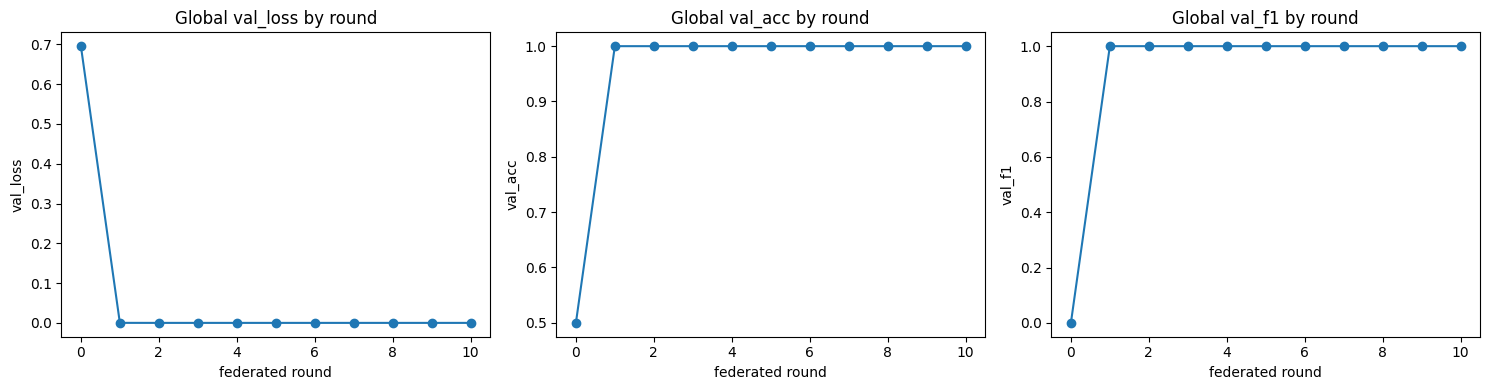

In [25]:
fig = evalmod.plot_federated_rounds(round_metrics)
plt.show()

## 16. Final global-model evaluation

Load the best-F1 global checkpoint and evaluate it **once** on the untouched
test set — the federated counterpart of Section 12.

In [26]:
global_model = build_model(input_dim, CONFIG)
global_model.load_state_dict(torch.load(cfgmod.GLOBAL_MODEL_PATH, map_location=device, weights_only=True))
fed_test = trainmod.evaluate(global_model, X_te, y_te, device, CONFIG.decision_threshold)
print("Federated global-model TEST metrics:")
print(evalmod.format_metrics(fed_test))
print(f"Confusion: TN={fed_test['tn']} FP={fed_test['fp']} FN={fed_test['fn']} TP={fed_test['tp']}")
print(f"FPR (false alarm)={fed_test['fpr']:.4f}  FNR (missed attack)={fed_test['fnr']:.4f}")

Federated global-model TEST metrics:
acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000 roc_auc=1.0000 pr_auc=1.0000
Confusion: TN=16638 FP=0 FN=0 TP=16638
FPR (false alarm)=0.0000  FNR (missed attack)=0.0000


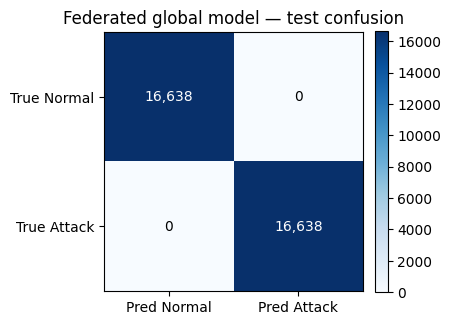

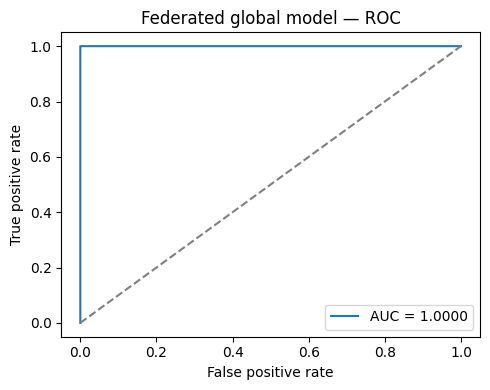

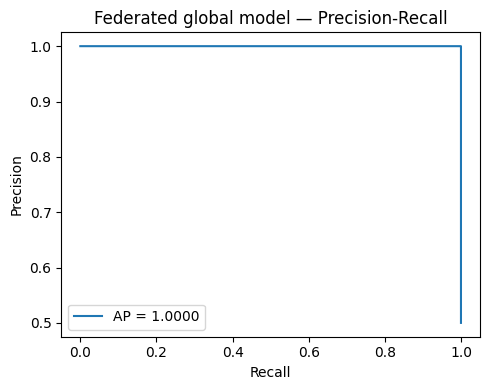

In [27]:
probs_fed = trainmod.predict_proba(global_model, X_te, device)
fig = evalmod.plot_confusion(fed_test, "Federated global model — test confusion")
plt.show()
fig = evalmod.plot_roc(y_te, probs_fed, "Federated global model — ROC")
plt.show()
fig = evalmod.plot_pr(y_te, probs_fed, "Federated global model — Precision-Recall")
plt.show()

## 17. Centralized vs Federated comparison

Side-by-side test metrics. We expect the federated model to closely match the
centralized baseline — the point of the exercise is that training never moved
the raw data off any client.

,metric,centralized,federated
0,accuracy,1.0,1.0
1,precision,1.0,1.0
2,recall,1.0,1.0
3,f1,1.0,1.0
4,roc_auc,1.0,1.0
5,pr_auc,1.0,1.0
6,fpr,0.0,0.0
7,fnr,0.0,0.0


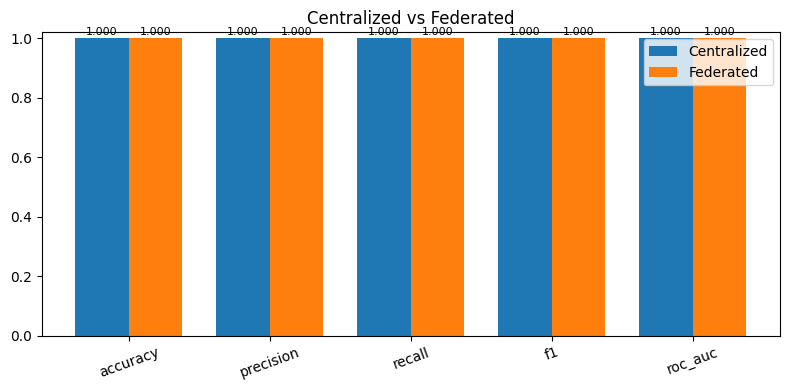

In [28]:
compare = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "fpr", "fnr"],
    "centralized": [cen_test[k] for k in ["accuracy","precision","recall","f1","roc_auc","pr_auc","fpr","fnr"]],
    "federated":   [fed_test[k] for k in ["accuracy","precision","recall","f1","roc_auc","pr_auc","fpr","fnr"]],
}).round(4)
display(compare)
fig = evalmod.plot_comparison(cen_test, fed_test)
plt.show()

## 18. Saving artifacts

Persist the round/client metrics and final results so they can be reviewed
without re-running the notebook.

In [29]:
round_metrics.to_csv(cfgmod.FED_ROUND_METRICS_PATH, index=False)
client_metrics.to_csv(cfgmod.CLIENT_METRICS_PATH, index=False)
with open(cfgmod.FINAL_FED_METRICS_PATH, "w") as f:
    json.dump({"test": fed_test, "best_round": fed["best"]["round"],
               "wall_time_s": fed["wall_time"]}, f, indent=2, default=str)
with open(cfgmod.FINAL_CENTRALIZED_METRICS_PATH, "w") as f:
    json.dump({"test": cen_test, "train_time_s": cen_train_time}, f, indent=2, default=str)

for p in [cfgmod.FED_ROUND_METRICS_PATH, cfgmod.CLIENT_METRICS_PATH,
          cfgmod.FINAL_FED_METRICS_PATH, cfgmod.FINAL_CENTRALIZED_METRICS_PATH,
          cfgmod.CLIENT_DISTRIBUTIONS_PATH, cfgmod.GLOBAL_MODEL_PATH,
          cfgmod.CENTRALIZED_MODEL_PATH, cfgmod.PREPROCESSOR_PATH]:
    print("saved:", p.relative_to(ROOT))

saved: results\federated_round_metrics.csv
saved: results\client_metrics.csv
saved: results\final_federated_metrics.json
saved: results\final_centralized_metrics.json
saved: results\client_distributions.csv
saved: artifacts\global_model.pt
saved: artifacts\centralized_model.pt
saved: artifacts\preprocessor.joblib


## 19. Inference example

`src/inference.py` loads the saved preprocessor + global model and scores raw
rows. We score a few **untouched** test rows (not cherry-picked), showing the
attack probability, predicted label/class, threshold, and the true label.

In [30]:
from src.inference import InferencePipeline
pipe = InferencePipeline()
demo = test_df.head(8).reset_index(drop=True)
pred = pipe.predict(demo)
for i in range(len(demo)):
    print(f"row {i}: prob={pred.loc[i,'attack_probability']:.4f}  "
          f"pred={int(pred.loc[i,'predicted_label'])} ({pred.loc[i,'predicted_class']})  "
          f"threshold={pred.loc[i,'threshold']:.2f}  [true={int(demo.loc[i, TARGET_COLUMN])}]")

row 0: prob=0.0001  pred=0 (Normal)  threshold=0.50  [true=0]
row 1: prob=0.0000  pred=0 (Normal)  threshold=0.50  [true=0]
row 2: prob=0.0000  pred=0 (Normal)  threshold=0.50  [true=0]
row 3: prob=0.0000  pred=0 (Normal)  threshold=0.50  [true=0]
row 4: prob=0.9999  pred=1 (Attack)  threshold=0.50  [true=1]
row 5: prob=0.0000  pred=0 (Normal)  threshold=0.50  [true=0]
row 6: prob=0.9999  pred=1 (Attack)  threshold=0.50  [true=1]
row 7: prob=0.0001  pred=0 (Normal)  threshold=0.50  [true=0]


## 20. Conclusions and limitations

**What we showed.** A complete, reproducible federated-learning workflow:
balanced sampling → leakage-aware cleaning → train-only preprocessing →
centralized baseline → IID 5-client partitioning → Flower FedAvg → single-shot
test evaluation. The federated global model matches the centralized baseline
without any client sharing its raw data.

**Limitations (honest).**
- **Near-perfect separability.** The DNN-EdgeIIoT *binary* task is trivially
  separable (Section 6): several protocol fields split the classes on their own,
  so both models hit ~99–100%. This is consistent with the literature but means
  the task does not stress the models — accuracy differences here are not
  meaningful signals of federated vs centralized quality.
- **IID only.** Real federated sites are usually non-IID; we intentionally
  implemented only IID partitioning for this first version.
- **Simulation, not deployment.** Clients are Ray actors on one machine, not
  real remote nodes; there is no network, secure aggregation or privacy layer.
- **Balanced subset.** We evaluate on a 50/50 subset, not the naturally
  imbalanced full stream, so absolute FPR/FNR would differ in production.

**Sensible next steps.** non-IID (Dirichlet) partitioning, class-imbalanced
evaluation, more rounds with partial client participation, and differential
privacy — all deliberately out of scope here.

---
### Technical decisions supported by research

- **Decision:** `BCEWithLogitsLoss` on a single logit output.
  **Reason:** combines sigmoid + BCE in one numerically stable op.
  **Source:** PyTorch docs (`torch.nn.BCEWithLogitsLoss`).
- **Decision:** `NumPyClient` + `run_simulation` + `FedAvg` (Flower 1.32).
  **Reason:** the supported, well-documented simulation path; maps directly onto
  "get params → train → return params+num_examples → weighted average".
  **Source:** Flower docs — *How to run simulations*, *FedAvg strategy*.
- **Decision:** sample-count-weighted FedAvg.
  **Reason:** standard FedAvg weights each client's update by its number of
  training examples. **Source:** McMahan et al. 2017; Flower `FedAvg`.
- **Decision:** clients on CPU, fractional/zero GPU.
  **Reason:** tiny MLP; avoids Ray+CUDA memory contention on a 6 GB GPU.
  **Source:** Flower docs — simulation resource allocation.
- **Decision:** fit preprocessing only on the training pool.
  **Reason:** prevents information leaking from val/test into scaling/imputation.
  **Source:** scikit-learn — common pitfalls / data leakage.
- **Decision:** SMOTE off by default.
  **Reason:** the subset is already balanced 50/50, so SMOTE adds nothing;
  applying it would only risk synthetic-sample leakage if misused.
  **Source:** imbalanced-learn docs (SMOTE intended for imbalanced training).